In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
import joblib

In [6]:
df=pd.read_csv("house_price_regression_dataset.csv")


In [7]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [8]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [9]:
df.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

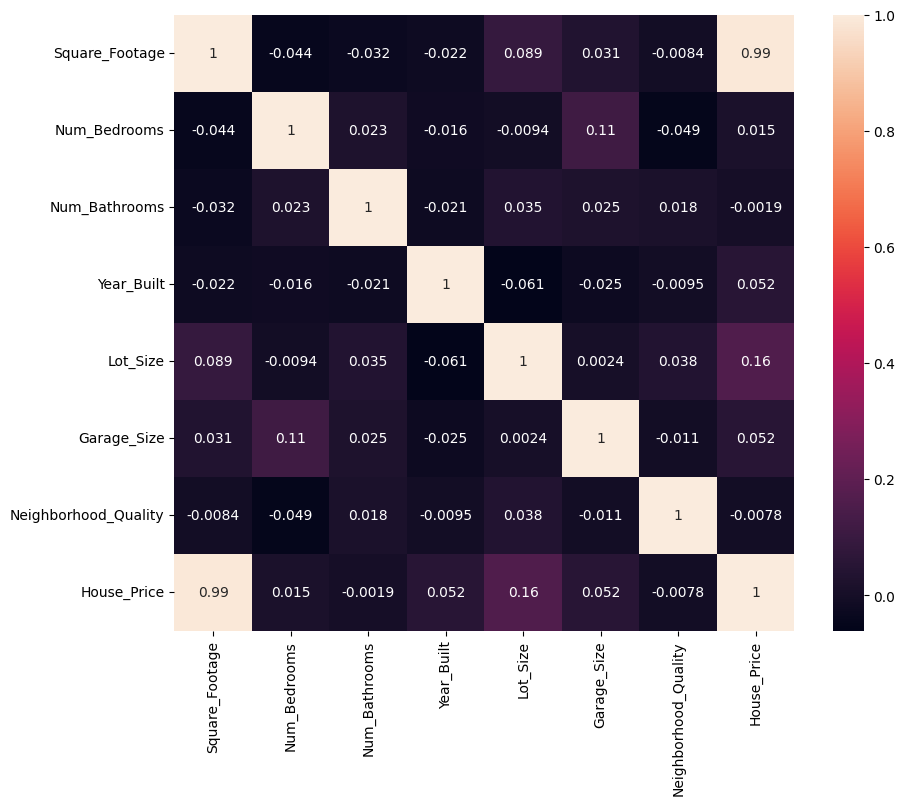

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [14]:
x=df.drop("House_Price",axis=1)

In [15]:
y=df["House_Price"]

In [19]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [21]:
lr=LinearRegression()
lr.fit(X_train,Y_train)
prediction=lr.predict(X_test)

In [22]:
mae=mean_absolute_error(Y_test,prediction)
print(mae)

8174.583600006653


In [23]:
mse=mean_squared_error(Y_test,prediction)
print(mse)

101434798.50563647


In [24]:
rmse=np.sqrt(mse)
print(rmse)

10071.484424137112


In [25]:
r2=r2_score(Y_test,prediction)
print(r2)

0.9984263636823413


In [27]:
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train,Y_train)
dt_pred=dt.predict(X_test)
print(r2_score(Y_test,dt_pred))

0.9846543343767692


In [32]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,Y_train)
rf_pred=rf.predict(X_test)
print(r2_score(Y_test,rf_pred))

0.9938851770748258


In [33]:
new_house=[[2000,3,2,5,6,8,9]]
new_house=scaler.transform(new_house)
price=rf.predict(new_house)
print(price)

[461524.17253354]


c:\Users\ajimal hassan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [34]:
joblib.dump(rf,"house_price_model.pkl")

['house_price_model.pkl']

In [36]:
model=joblib.load("house_price_model.pkl")